# Word2Vec

#### What are good quality word embedding and how to generate them?

The simplest word embedding you can have is using one-hot vectors. If you have 10,000 words in your vocabulary, then you can represent each word as a 1x10,000 vector.

For a simple example, if we have 4 words — mango, strawberry, city, Delhi — in our vocabulary then we can represent them as following:

Mango [1, 0, 0, 0]

Strawberry [0, 1, 0, 0]

City [0, 0, 1, 0]

Delhi [0, 0, 0, 1]

There are a few problems with the above approach, firstly, our size of vectors depends on the size of our vocabulary(which can be huge). This is a wastage of space and increases algorithm complexity exponentially resulting in the curse of dimensionality.

Secondly, these embedding will be closely coupled to their applications, making transfer-learning to a model using a different vocabulary of the same size, adding/removing words from vocabulary would almost impossible as it would require to re-train the whole model again.

Lastly, the entire purpose of creating embedding is to capture the contextual meaning of the words, which this representation fails to do. There is no co-relation between words that have similar meaning or usage.

###### Current situation
Similarity(Mango, Strawberry) == Similarity(Mango, City) == 0
##### Ideal situation
Similarity(Mango, Strawberry) >> Similarity(Mango, City)
** Note: Similarity(a,b) = a.b/(||a||*||b||) Cosine similarity

### Word2vec

It is one of the most popular technique to learn word embeddings using a two-layer neural network. Its input is a text corpus and its output is a set of vectors. Word embedding via word2vec can make natural language computer-readable, then further implementation of mathematical operations on words can be used to detect their similarities. A well-trained set of word vectors will place similar words close to each other in that space. For instance, the words women, men, and human might cluster in one corner, while yellow, red and blue cluster together in another.

There are two main training algorithms for word2vec, one is the continuous bag of words(CBOW), another is called skip-gram. The major difference between these two methods is that CBOW is using context to predict a target word while skip-gram is using a word to predict a target context. Generally, the skip-gram method can have a better performance compared with CBOW method, for it can capture two semantics for a single word. For instance, it will have two vector representations for Apple, one for the company and another for the fruit.

In the CBOW model, the distributed representations of context (or surrounding words) are combined to predict the word in the middle. While in the Skip-gram model, the distributed representation of the input word is used to predict the context.

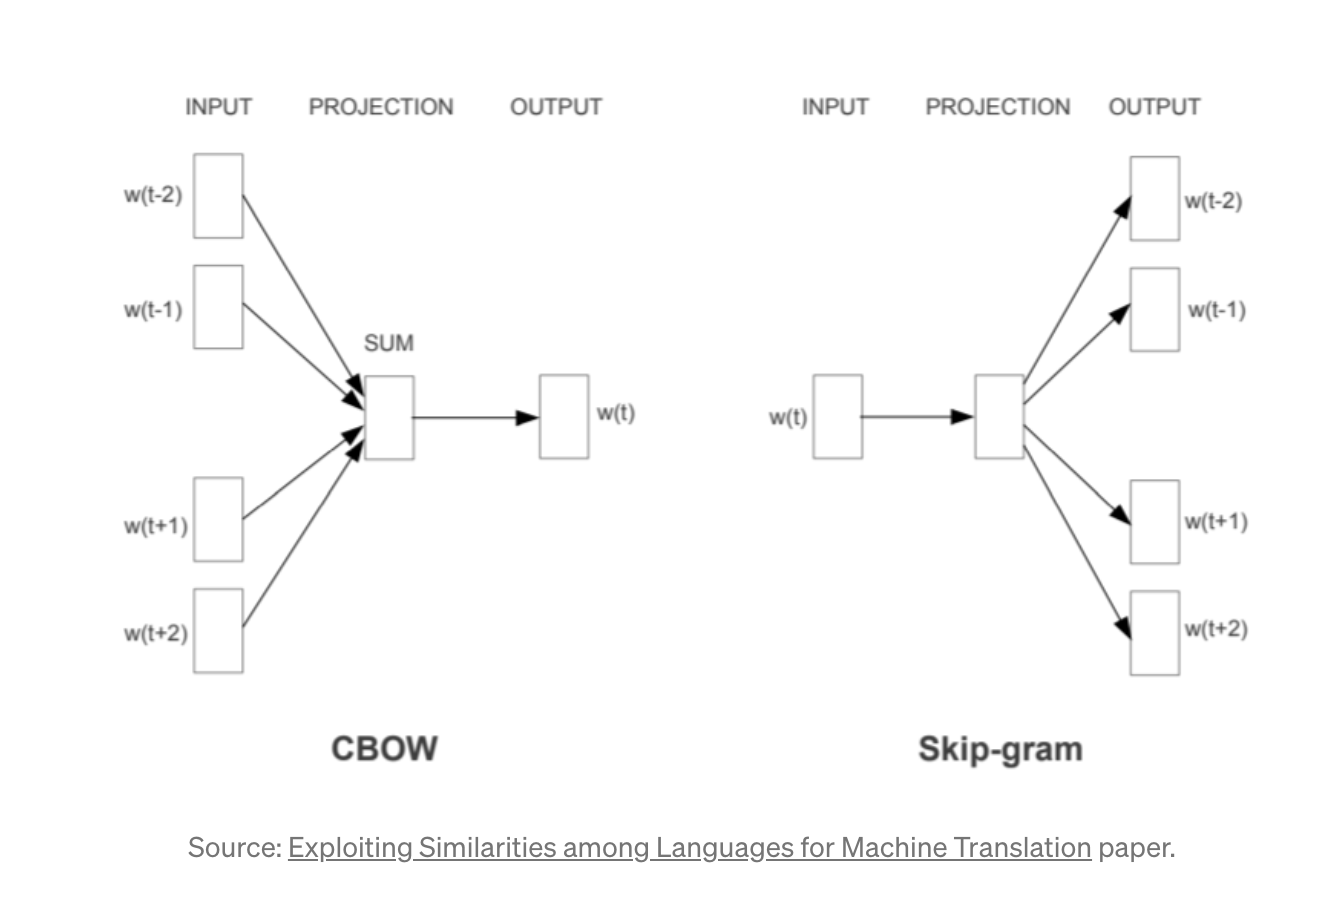

### Skip-gram Model

We’ll do so by creating a “fake” task for the neural network to train. We won’t be interested in the inputs and outputs of this network, rather the goal is actually just to learn the weights of the hidden layer that are actually the “word vectors” that we’re trying to learn.

The fake task for Skip-gram model would be, given a word, we’ll try to predict its neighboring words. We’ll define a neighboring word by the window size — a hyper-parameter.

Given the sentence:
“I will have orange juice and eggs for breakfast.”

and a window size of 2, if the target word is juice, its neighboring words will be ( have, orange, and, eggs). Our input and target word pair would be (juice, have), (juice, orange), (juice, and), (juice, eggs).

Also note that within the sample window, proximity of the words to the source word plays no role. So have, orange, and, and eggs will be treated the same while training.



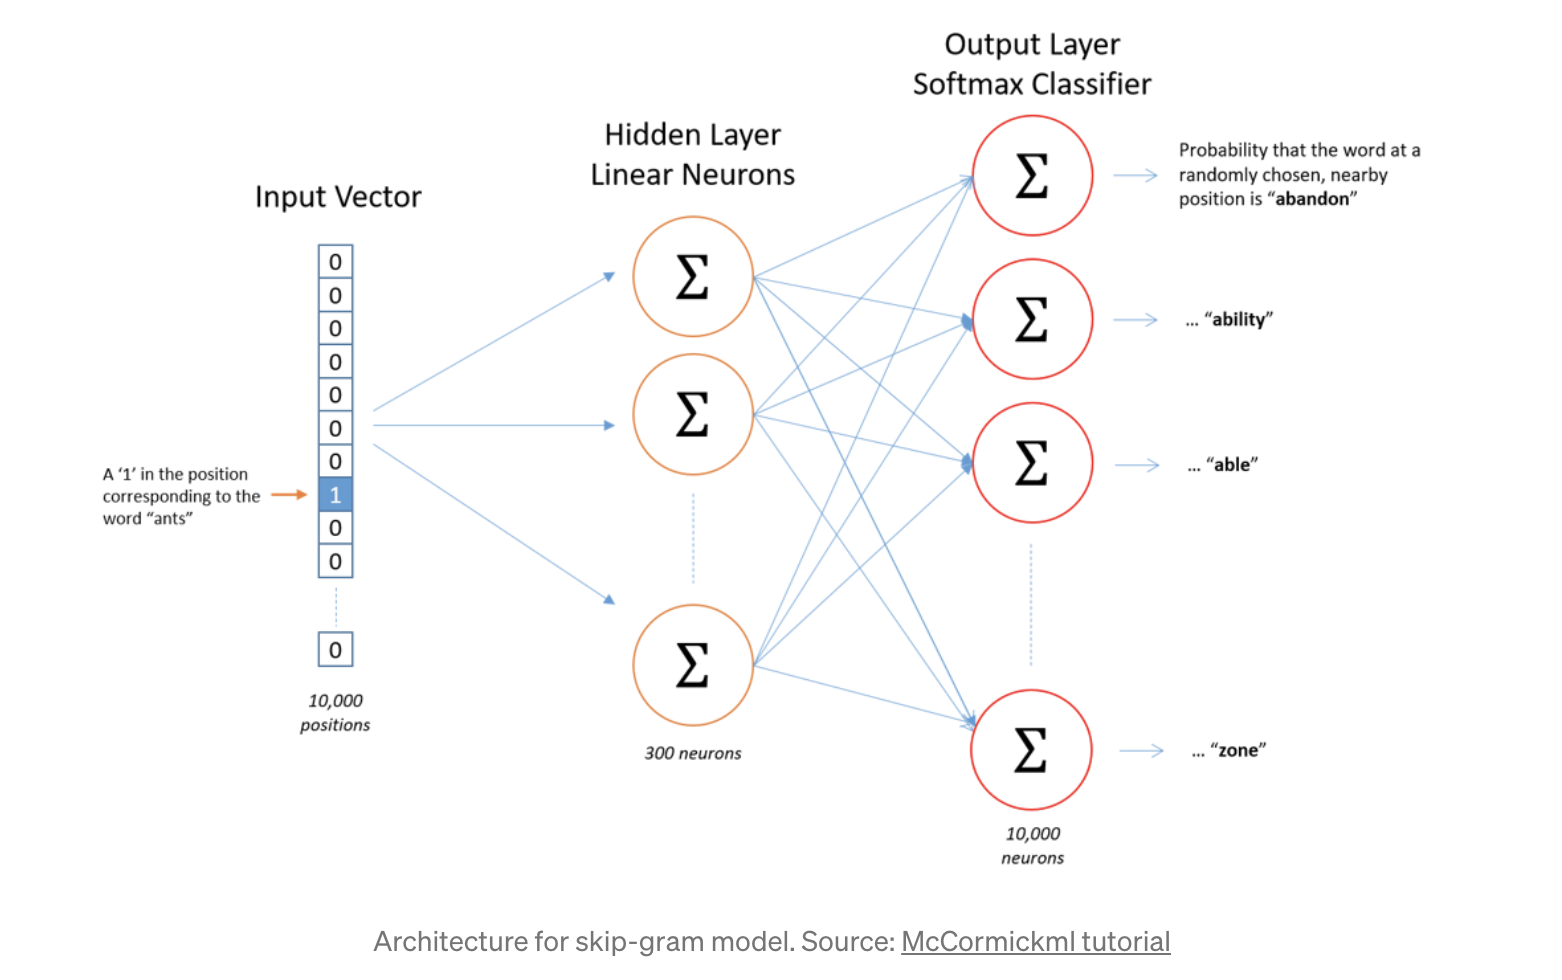

 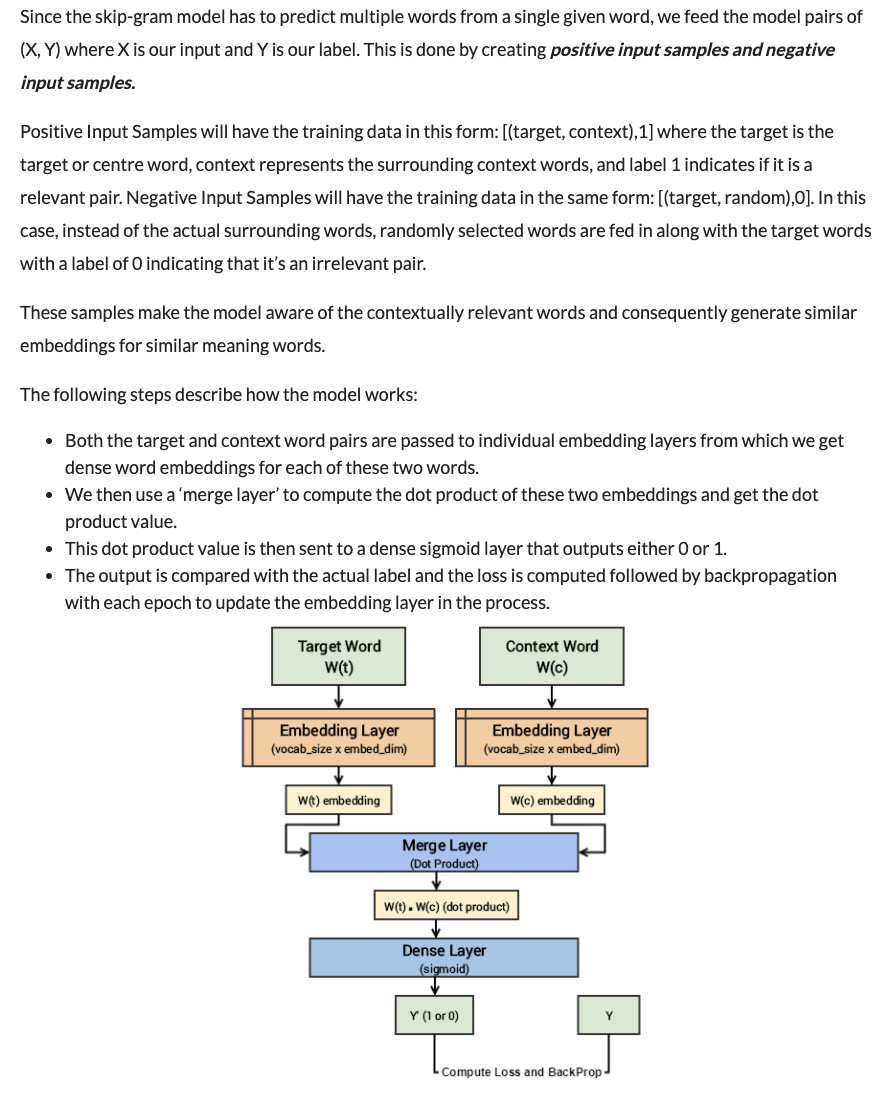

The dimensions of the input vector will be 1xV — where V is the number of words in the vocabulary — i.e one-hot representation of the word. The single hidden layer will have dimension VxE, where E is the size of the word embedding and is a hyper-parameter. The output from the hidden layer would be of the dimension 1xE, which we will feed into an softmax layer. The dimensions of the output layer will be 1xV, where each value in the vector will be the probability score of the target word at that position.
According to our earlier example if we have a vector [0.2, 0.1, 0.3, 0.4], the probability of the word being mango is 0.2, strawberry is 0.1, city is 0.3 and Delhi is 0.4.

The back propagation for training samples corresponding to a source word is done in one back pass. So for juice, we will complete the forward pass for all 4 target words ( have, orange, and, eggs). We will then calculate the errors vectors[1xV dimension] corresponding to each target word. We will now have 4 1xV error vectors and will perform an element-wise sum to get a 1xV vector. The weights of the hidden layer will be updated based on this cumulative 1xV error vector.

### CBOW

The fake task in CBOW is somewhat similar to Skip-gram, in the sense that we still take a pair of words and teach the model that they co-occur but instead of adding the errors we add the input words for the same target word.

The dimension of our hidden layer and output layer will remain the same. Only the dimension of our input layer and the calculation of hidden layer activations will change, if we have 4 context words for a single target word, we will have 4 1xV input vectors. Each will be multiplied with the VxE hidden layer returning 1xE vectors. All 4 1xE vectors will be averaged element-wise to obtain the final activation which then will be fed into the softmax layer.

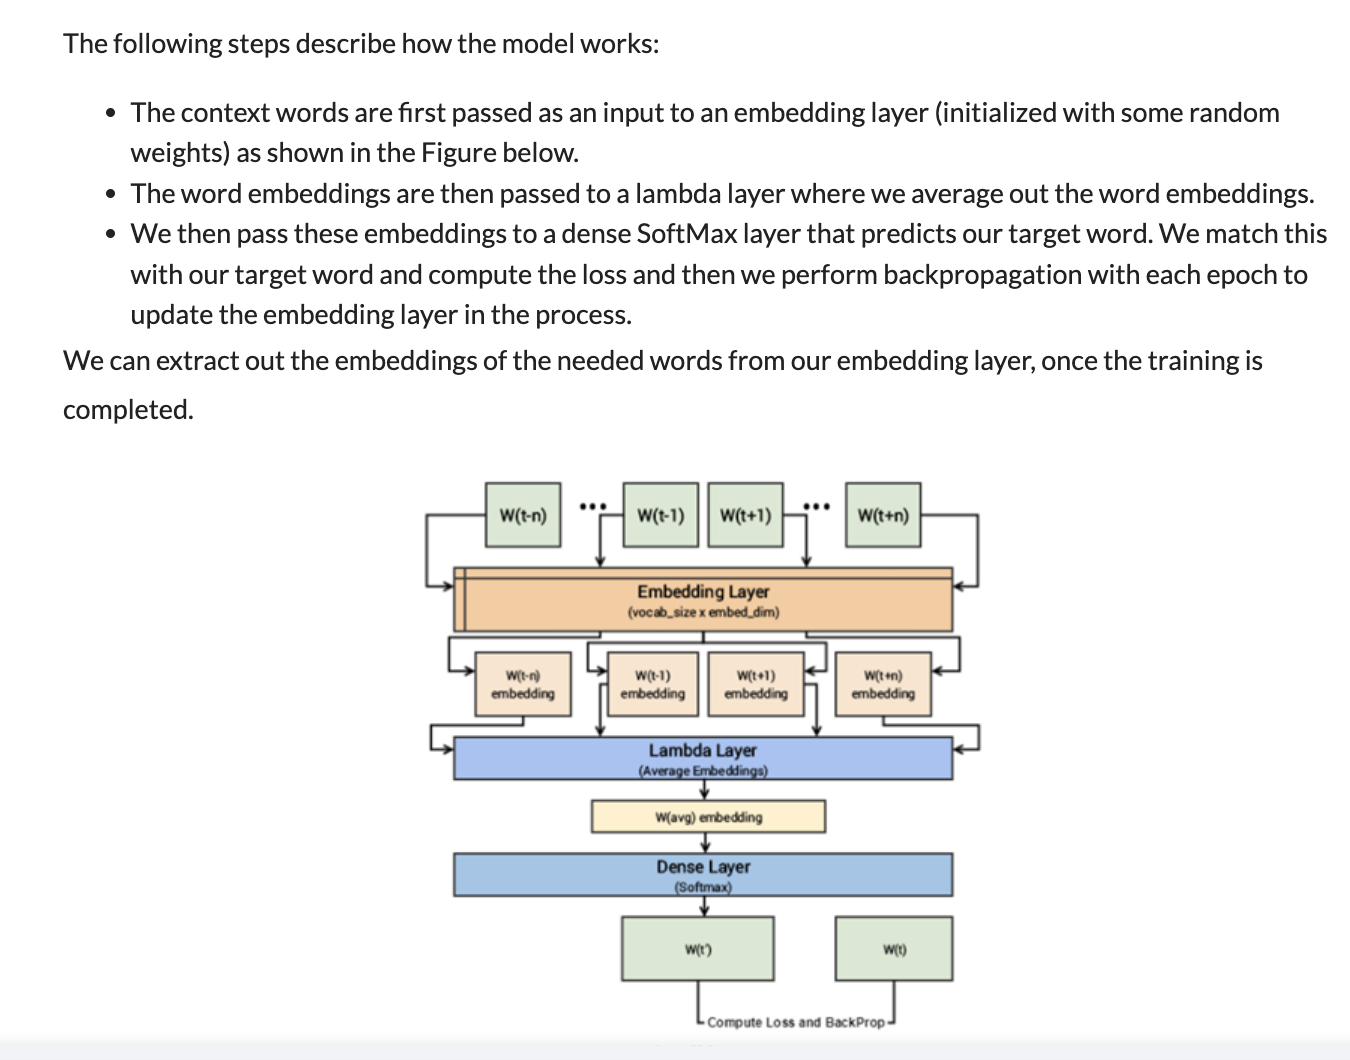

### Difference bw CBOW & Skip-Gram

Skip-gram: works well with a small amount of the training data, represents well even rare words or phrases.
CBOW: several times faster to train than the skip-gram, slightly better accuracy for the frequent words.



In CBOW's case, the neural network's word embeddings are trained by passing a input set of words to the neural network and making the network to predict an output word as shown below:

{𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}→𝑇ℎ𝑒

{𝑇ℎ𝑒,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}→𝑐𝑎𝑡

{𝑇ℎ𝑒,𝑐𝑎𝑡,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}→𝑗𝑢𝑚𝑝𝑒𝑑

{𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}→𝑜𝑣𝑒𝑟

{𝑇ℎ𝑒,𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑝𝑢𝑑𝑑𝑙𝑒}→𝑡ℎ𝑒

{𝑇ℎ𝑒,𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒}→𝑝𝑢𝑑𝑑𝑙𝑒

In skip-gram's case, the neural network's word embeddings are trained by passing an input word to the neural network and teaching the network to predict a set of words as shown below:

𝑇ℎ𝑒→{𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}

𝑐𝑎𝑡→{𝑇ℎ𝑒,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}

𝑗𝑢𝑚𝑝𝑒𝑑→{𝑇ℎ𝑒,𝑐𝑎𝑡,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}

𝑜𝑣𝑒𝑟→{𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑡ℎ𝑒,𝑝𝑢𝑑𝑑𝑙𝑒}

𝑡ℎ𝑒→{𝑇ℎ𝑒,𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑝𝑢𝑑𝑑𝑙𝑒}

𝑝𝑢𝑑𝑑𝑙𝑒→{𝑇ℎ𝑒,𝑐𝑎𝑡,𝑗𝑢𝑚𝑝𝑒𝑑,𝑜𝑣𝑒𝑟,𝑡ℎ𝑒}

For usage, if you are thinking of a fill-in-the-blanks kind of problem CBOW Word2Vec would be a suitable vector to use, on the other hand if you have a word and you are trying to come up with a new sentence with it then skip-gram Word2Vec will be useful.



In [1]:
!pip install gensim

import nltk
nltk.download('punkt')
nltk.download('stopwords')
#import word2vec from gensim.models,import stopwords from nltk.corpus,import re
from gensim.models import Word2Vec
from nltk.corpus import stopwords
import re

paragraph = """I have three visions for India. In 3000 years of our history, people from all over
               the world have come and invaded us, captured our lands, conquered our minds.
               From Alexander onwards, the Greeks, the Turks, the Moguls, the Portuguese, the British,
               the French, the Dutch, all of them came and looted us, took over what was ours.
               Yet we have not done this to any other nation. We have not conquered anyone.
               We have not grabbed their land, their culture,
               their history and tried to enforce our way of life on them.
               Why? Because we respect the freedom of others.That is why my
               first vision is that of freedom. I believe that India got its first vision of
               this in 1857, when we started the War of Independence. It is this freedom that
               we must protect and nurture and build on. If we are not free, no one will respect us.
               My second vision for India’s development. For fifty years we have been a developing nation.
               It is time we see ourselves as a developed nation. We are among the top 5 nations of the world
               in terms of GDP. We have a 10 percent growth rate in most areas. Our poverty levels are falling.
               Our achievements are being globally recognised today. Yet we lack the self-confidence to
               see ourselves as a developed nation, self-reliant and self-assured. Isn’t this incorrect?
               I have a third vision. India must stand up to the world. Because I believe that unless India
               stands up to the world, no one will respect us. Only strength respects strength. We must be
               strong not only as a military power but also as an economic power. Both must go hand-in-hand.
               My good fortune was to have worked with three great minds. Dr. Vikram Sarabhai of the Dept. of
               space, Professor Satish Dhawan, who succeeded him and Dr. Brahm Prakash, father of nuclear material.
               I was lucky to have worked with all three of them closely and consider this the great opportunity of my life.
               I see four milestones in my career"""

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.9 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


##### Preprocessing the data

In [2]:
text = re.sub(r'\[[0-9]*\]',' ',paragraph)
text = re.sub(r'\s+',' ',text)
text = text.lower()
text = re.sub(r'\d',' ',text)
text = re.sub(r'\s+',' ',text)


### Preparing the dataset

In [3]:
nltk.download('punkt_tab')

sentences = nltk.sent_tokenize(text)
sentences = [nltk.word_tokenize(sentence) for sentence in sentences]
for i in range(len(sentences)):
    sentences[i] = [word for word in sentences[i] if word not in stopwords.words('english')]

sentences[1]



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['years',
 'history',
 ',',
 'people',
 'world',
 'come',
 'invaded',
 'us',
 ',',
 'captured',
 'lands',
 ',',
 'conquered',
 'minds',
 '.']

In [4]:
model = Word2Vec(sentences, min_count=1)
words = model.wv.index_to_key
print(words)

['.', ',', 'india', 'must', 'vision', 'nation', 'us', 'world', 'see', 'freedom', 'respect', 'three', 'dr.', 'great', 'worked', 'power', 'strength', 'developed', '’', 'one', 'believe', 'first', '?', 'life', 'yet', 'minds', 'conquered', 'history', 'years', 'career', 'milestones', 'four', 'opportunity', 'consider', 'closely', 'lucky', 'material', 'nuclear', 'father', 'prakash', 'brahm', 'succeeded', 'dhawan', 'satish', 'professor', 'space', 'dept', 'sarabhai', 'vikram', 'fortune', 'good', 'hand-in-hand', 'go', 'economic', 'also', 'military', 'strong', 'respects', 'stands', 'unless', 'stand', 'third', 'incorrect', 'self-assured', 'self-reliant', 'self-confidence', 'lack', 'today', 'recognised', 'globally', 'achievements', 'falling', 'levels', 'poverty', 'areas', 'rate', 'growth', 'percent', 'gdp', 'terms', 'nations', 'top', 'among', 'time', 'developing', 'fifty', 'development', 'second', 'free', 'build', 'nurture', 'protect', 'independence', 'war', 'started', 'got', 'others.that', 'way', '

### Finding Word Vectors

In [5]:
#vector = model.wv['war']
vector = model.wv['war']
#print vector
print(vector)
print("dimensions of the vector:",vector.shape)


similar = model.wv.most_similar('time')
for i in similar:
  print(i)

[-2.9304232e-03  4.9140467e-03 -1.6355860e-03 -9.2051383e-03
 -3.2627825e-03  6.8555875e-03  5.2624857e-03  4.4279387e-03
  6.1624008e-03 -9.1385683e-03  1.0934445e-03  3.9344132e-03
 -2.4514750e-03 -2.7655778e-03  6.3546342e-03 -8.4966477e-03
  3.3586284e-03  4.1426918e-03  2.0429869e-03  3.8802470e-03
 -6.6453875e-03  2.4616681e-03 -1.5360069e-03 -3.7597807e-03
  8.8545205e-03 -7.4667572e-03 -7.5152861e-03 -5.9132562e-03
 -8.8900775e-03 -1.8858764e-03 -8.7505039e-03 -4.3067266e-03
  5.8609117e-03 -2.2527010e-03 -6.0235597e-03 -3.7154499e-03
 -7.1363570e-03  8.4930137e-03  3.6354368e-03 -4.6406185e-05
  9.6904552e-03  7.4704955e-03 -5.3539886e-03 -7.8825261e-03
  6.0094381e-03  5.9018703e-03 -2.6045367e-03  5.6043402e-03
  8.7628970e-03  2.9020978e-03 -5.7307361e-03 -1.2098058e-03
 -7.1481834e-03  8.0581736e-03 -4.6889978e-03  4.0846695e-03
  6.1002541e-03 -8.0227264e-04 -2.0651688e-04  7.9131331e-03
 -4.7337869e-03  9.8994505e-03  4.1475138e-03  3.3647076e-03
 -2.6712241e-03 -3.25053